---
title: Global precipitation climatology and ITCZ migration from GPM IMERG
author: Harsha R. Hampapura
date: 2026-09-10
---

## Global precipitation climatology and the migrating tropical rain belt

[GPM IMERG Final (monthly)](https://gdex.ucar.edu/datasets/d736000/) is NASA's
satellite-and-gauge precipitation product. It comes from **GPM**, the
[Global Precipitation Measurement](https://climatedataguide.ucar.edu/climate-data/gpm-global-precipitation-measurement-mission)
mission — an international NASA–JAXA satellite constellation that estimates
rainfall worldwide — and **IMERG** (*Integrated Multi-satellitE Retrievals for
GPM*), the algorithm that blends those microwave and infrared observations into a
single **global, 0.1°** map of the monthly-mean precipitation rate. GDEX's copy
spans **June 2000 – October 2025**; the earliest years lean on GPM's predecessor,
[**TRMM**](https://climatedataguide.ucar.edu/climate-data/trmm-tropical-rainfall-measuring-mission)
(the *Tropical Rainfall Measuring Mission*, 1997–2015). The satellite estimates
are bias-corrected against ground rain-gauge records.

In this notebook we

1. open the full ~25-year monthly record from GDEX,
2. average it in time to map the **global precipitation climatology** (the
   long-term average rainfall pattern) — revealing the **Intertropical
   Convergence Zone (ITCZ)**, the band of heavy rain where the trade winds meet
   near the equator, along with the monsoons and the dry subtropical deserts, then
3. average around each latitude circle to show how that rain belt **migrates**
   north and south with the seasons.

In [1]:
# Imports
import os
import calendar
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Open the dataset

IMERG is distributed as hundreds of monthly
[HDF5](https://climatedataguide.ucar.edu/formats/hdf) granules. GDEX adds a
**kerchunk** reference — a single JSON index recording which byte range of which
granule holds each chunk — so one `xr.open_dataset(..., engine="kerchunk")` call
presents the whole record as one virtual `xarray.Dataset`, and you stream only the
chunks you actually use.

GDEX publishes the reference in two forms we care about:

| Form | When to use it |
|------|----------------|
| **POSIX** (`/gdex/data/...`) | on a machine that mounts `/gdex/data` — NCAR HPC and CIRRUS Binder |
| **OSDF** (`...-remote-osdf.json`) | off-cluster (laptop, other hubs); chunks stream over the OSDF cache network |

The cell below selects POSIX when the mount is present and falls back to OSDF, so
the notebook runs unchanged in either place. The OSDF form's chunk URLs use the
`osdf://` scheme, resolved by
[pelicanfs](https://github.com/PelicanPlatform/pelicanfs) (installed via
`environment.yml`; fsspec registers it automatically).

In [2]:
# Where to read the IMERG monthly kerchunk reference from — POSIX if the GDEX
# data mount is present, otherwise the OSDF-routed reference over the web.
posix_ref = "/gdex/data/d736000/kerchunk/GPM_3IMERGM_v07.json"
osdf_ref  = "https://data.gdex.ucar.edu/d736000/kerchunk/GPM_3IMERGM_v07-remote-osdf.json"

kerchunk_ref = posix_ref if os.path.exists(posix_ref) else osdf_ref
print(f"Access: {'POSIX mount' if kerchunk_ref == posix_ref else 'OSDF (remote)'}")
print(kerchunk_ref)

Access: POSIX mount
/gdex/data/d736000/kerchunk/GPM_3IMERGM_v07.json


### Inspect the precipitation field

The monthly-mean rain rate lives in the **`precipitation`** variable. Two things
to note before we compute:

- its dimensions are ordered **`(time, lon, lat)`** — longitude before latitude —
  so we transpose to `(lat, lon)` when mapping;
- its units are **mm/hr**; we convert to the more intuitive **mm/day** (× 24) for
  the plots.

Opening with `chunks={}` keeps the array lazy (Dask-backed) using the reference's
native chunking, so nothing is read until we reduce it.

In [3]:
ds = xr.open_dataset(kerchunk_ref, engine="kerchunk", chunks={})
precip = ds["precipitation"]        # (time, lon, lat), mm/hr
precip

<xarray.DataArray 'precipitation' (time: 304, lon: 3600, lat: 1800)> Size: 8GB
dask.array<open_dataset-precipitation, shape=(304, 3600, 1800), dtype=float32, chunksize=(1, 145, 1800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2kB 2000-06-01 00:00:00 ... 2025-09-01 00:00:00
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.8 179.9
  * lat      (lat) float32 7kB -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
Attributes:
    CodeMissingValue:  -9999.9
    DimensionNames:    time,lon,lat
    LongName:          Merged microwave-infrared-gauge precipitation estimate
    Units:             mm/hr
    units:             mm/hr

## Global precipitation climatology

Averaging the full 304-month record gives the long-term mean rain rate at every
0.1° pixel. We convert mm/hr → mm/day for readability.

:::{note} This reduction streams the whole ~7 GB array
The mean touches every chunk, so expect **a few minutes** the first time (faster
from the POSIX mount than over OSDF). Memory stays low because Dask reduces
chunk-by-chunk rather than loading everything at once.
:::

In [4]:
%%time
# Average over all months, then convert mm/hr -> mm/day. Result is one (lat, lon) map.
clim = precip.where(precip >= 0).mean("time")
clim = (clim * 24.0).transpose("lat", "lon")
clim.attrs["units"] = "mm/day"
clim = clim.compute()
clim

CPU times: user 1min 28s, sys: 10.5 s, total: 1min 38s
Wall time: 3min 37s


<xarray.DataArray 'precipitation' (lat: 1800, lon: 3600)> Size: 26MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 7kB -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.8 179.9
Attributes:
    CodeMissingValue:  -9999.9
    DimensionNames:    time,lon,lat
    LongName:          Merged microwave-infrared-gauge precipitation estimate
    Units:             mm/hr
    units:             mm/day

### Map the climatology

On a global map the long-term mean highlights the ITCZ as a bright band of heavy
rain near the equator, flanked by the dry subtropical deserts and ocean highs, and
by the mid-latitude storm tracks.

In [5]:
# Shared precipitation palette: white (dry) -> greens -> warm (wet).
from matplotlib.colors import LinearSegmentedColormap

PRECIP_CMAP = LinearSegmentedColormap.from_list(
    "precip_white_warm",
    ["#ffffff", "#d9f0a3", "#addd8e", "#41ab5d",
     "#fee391", "#fe9929", "#e31a1c", "#800026"],)

range: 0.00 – 29.05 mm/day


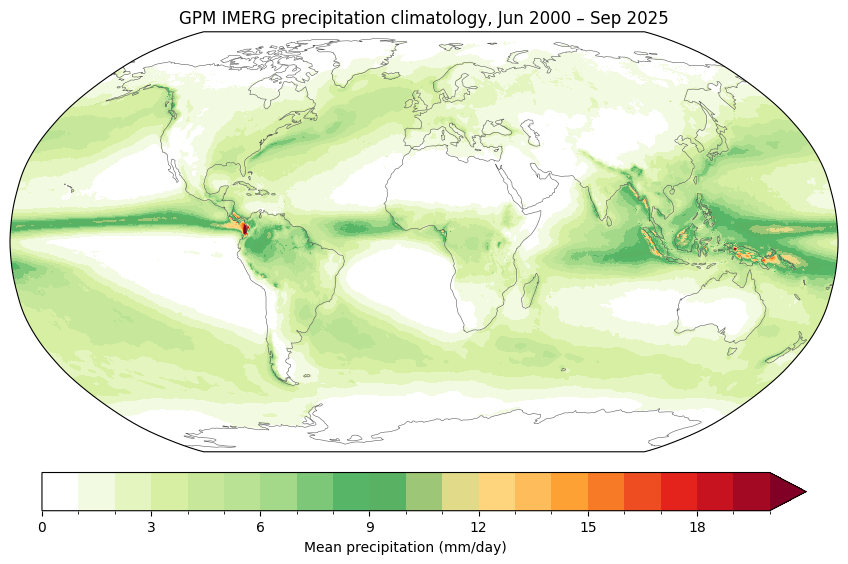

In [6]:
print(f"range: {float(clim.min()):.2f} – {float(clim.max()):.2f} mm/day")

plot = clim.coarsen(lat=2, lon=2, boundary="trim").mean()   # 0.1° -> 0.2°, lighter figure

clim_levels = np.arange(0, 21, 1)                           # mm/day
clim_norm   = BoundaryNorm(clim_levels, PRECIP_CMAP.N, extend="max")

fig, ax = plt.subplots(figsize=(11, 5.5),
                       subplot_kw={"projection": ccrs.Robinson()},
                       constrained_layout=True)
p = ax.pcolormesh(plot["lon"], plot["lat"], plot,
                  transform=ccrs.PlateCarree(),
                  cmap=PRECIP_CMAP, norm=clim_norm,
                  shading="auto", rasterized=True)
ax.coastlines(linewidth=0.4, color="0.35")
ax.set_global()
cb = plt.colorbar(p, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04, extend="max")
cb.set_label("Mean precipitation (mm/day)")
ax.set_title("GPM IMERG precipitation climatology, Jun 2000 – Sep 2025")
plt.show()

## The seasonal cycle, animated

NASA's [IMERG monthly climatology](https://svs.gsfc.nasa.gov/5241/) shows the
tropical rain belt breathing north and south across the year. We reproduce it here
from the same data: twelve monthly-mean maps, played as a loop. Watch the ITCZ and
the monsoons swing into the summer hemisphere each half-year.

In [7]:
%%time
# 12-month climatology maps (mm/day), coarsened for a light animation.
monthly = precip.where(precip >= 0).groupby("time.month").mean("time")   # (month, lon, lat)
monthly_map = (monthly * 24.0).transpose("month", "lat", "lon")
monthly_map = monthly_map.coarsen(lat=2, lon=2, boundary="trim").mean().compute()
monthly_map.attrs["units"] = "mm/day"
print("shape:", monthly_map.shape, "| max:", float(monthly_map.max()))

shape: (12, 900, 1800) | max: 45.51046371459961
CPU times: user 1min 17s, sys: 9.36 s, total: 1min 26s
Wall time: 1min 46s


In [8]:
anim_levels = np.arange(0, 26, 1)                           # mm/day
anim_norm   = BoundaryNorm(anim_levels, PRECIP_CMAP.N, extend="max")

lat, lon = monthly_map["lat"], monthly_map["lon"]

fig, ax = plt.subplots(figsize=(10, 5),
                       subplot_kw={"projection": ccrs.PlateCarree()},
                       constrained_layout=True)
ax.set_global()
ax.coastlines(linewidth=0.4, color="0.35")

mesh = ax.pcolormesh(lon, lat, monthly_map.isel(month=0),
                     transform=ccrs.PlateCarree(), cmap=PRECIP_CMAP, norm=anim_norm,
                     shading="auto", rasterized=True)
cb = plt.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.7, pad=0.05, extend="max")
cb.set_label("Precipitation (mm/day)")
title = ax.set_title("")

def update(m):
    mesh.set_array(monthly_map.isel(month=m).values.ravel())
    title.set_text(f"GPM IMERG climatology — {calendar.month_name[m + 1]}")
    return mesh, title

anim = animation.FuncAnimation(fig, update, frames=12, interval=700, blit=False)
plt.close(fig)

from IPython.display import HTML
HTML(anim.to_jshtml())